In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [ ]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [ ]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here
def epsilon_greedy_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])


In [ ]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [ ]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

# Write your code here
epsilon = epsilon_start

for episode_num in range(num_episodes):

    episode = generate_episode(epsilon)

    G = 0
    visited = set()
    total_reward = 0

    for state, action, reward in reversed(episode):

        G = gamma * G + reward
        total_reward += reward

        if (state, action) not in visited:
            visited.add((state, action))

            Q[state, action] += alpha * (G - Q[state, action])

    episode_rewards.append(total_reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if (episode_num + 1) % 2000 == 0:
        print(
            f"Episode {episode_num + 1}, "
            f"Epsilon: {epsilon:.4f}, "
            f"Average Reward: {np.mean(episode_rewards[-1000:]):.3f}"
        )

Episode 2000, Epsilon: 0.3678, Average Reward: 0.400
Episode 4000, Epsilon: 0.1353, Average Reward: 0.783
Episode 6000, Epsilon: 0.0500, Average Reward: 0.920
Episode 8000, Epsilon: 0.0500, Average Reward: 0.939
Episode 10000, Epsilon: 0.0500, Average Reward: 0.944
Episode 12000, Epsilon: 0.0500, Average Reward: 0.925
Episode 14000, Epsilon: 0.0500, Average Reward: 0.958
Episode 16000, Epsilon: 0.0500, Average Reward: 0.942
Episode 18000, Epsilon: 0.0500, Average Reward: 0.944
Episode 20000, Epsilon: 0.0500, Average Reward: 0.951


In [ ]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [ ]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:          ")
    print("Register Number:      ")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.818 0.817 0.949 0.636]
 [0.733 0.    0.959 0.59 ]
 [0.76  0.969 0.707 0.789]
 [0.714 0.    0.449 0.301]
 [0.583 0.839 0.    0.547]
 [0.    0.    0.    0.   ]
 [0.    0.979 0.    0.896]
 [0.    0.    0.    0.   ]
 [0.68  0.    0.865 0.696]
 [0.782 0.781 0.951 0.   ]
 [0.877 0.99  0.    0.89 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.882 0.901 0.947]
 [0.967 0.989 1.    0.84 ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.949 0.959 0.969 0.714]
 [0.839 0.    0.979 0.   ]
 [0.865 0.951 0.99  0.   ]
 [0.    0.947 1.    0.   ]]
Name:          
Register Number:      

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'U' 'R' 'L']]

Average reward over last 1000 episodes: 0.951


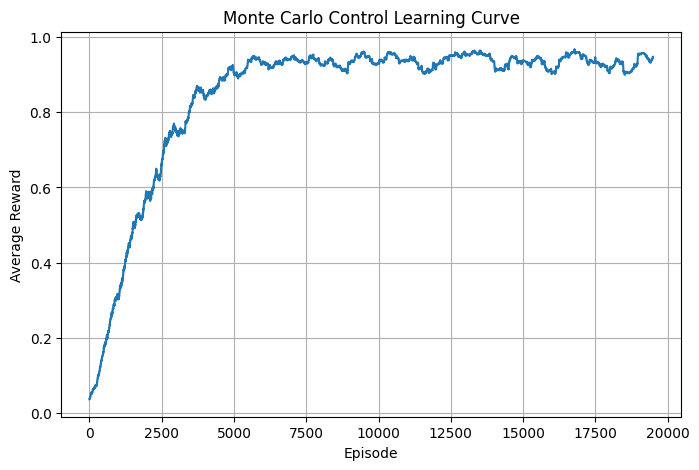

In [ ]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()